# Assignment 1

This assignment covers material from Weeks 1–4. Think of it as a spot-check: five exercises that test important analytical and visualization skills from the first part of the course.

## Formalia:

<mark>Please read the **[assignment overview page](https://github.com/suneman/socialdata2026/wiki/Assignments)** carefully before proceeding.</mark> This page contains information about formatting (including formats etc.), group sizes, and many other aspects of handing in the assignment. 

***If you fail to follow these simple instructions, it will negatively impact your grade!***

**Due date and time**: The assignment is due on Monday March 2nd, 2026 at 23:55. Hand in your files via DTU Learn. 

## Important Notes:
**All exercises use your combined SF crime dataset** (2003–present) that you built during Week 2, along with your Personal Focus Crimes. Make sure you have those ready before you start.
* **Hint**: The number of focus crimes are up to you, but choosing very few focus-crimes (1-5, let's say) feels like taking the easy way out to me, so to get top marks, you'll need 8 or more focus crimes (but it's not that more are better, 16 isn't necessarily better than 8).

Each assignment draws directly on the weekly exercises - you should be able to pull your work directly from there.

<div class="alert alert-block alert-info">
The same LLM guidance applies here as during the weekly exercises: use your LLM freely for coding, pandas syntax, and plot formatting. Do not use it for interpretation, reflection, or anything that asks for your own thinking. 
<br>  <br>
If you use and LLM to cheat, you are missing out on your education ... it will mean that you're not getting all you can out of this class ... and, more importantly, that you are literally wasting this crucial time of your DTU-journey, designed to make you smarter and ready for the world.
</div>

---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

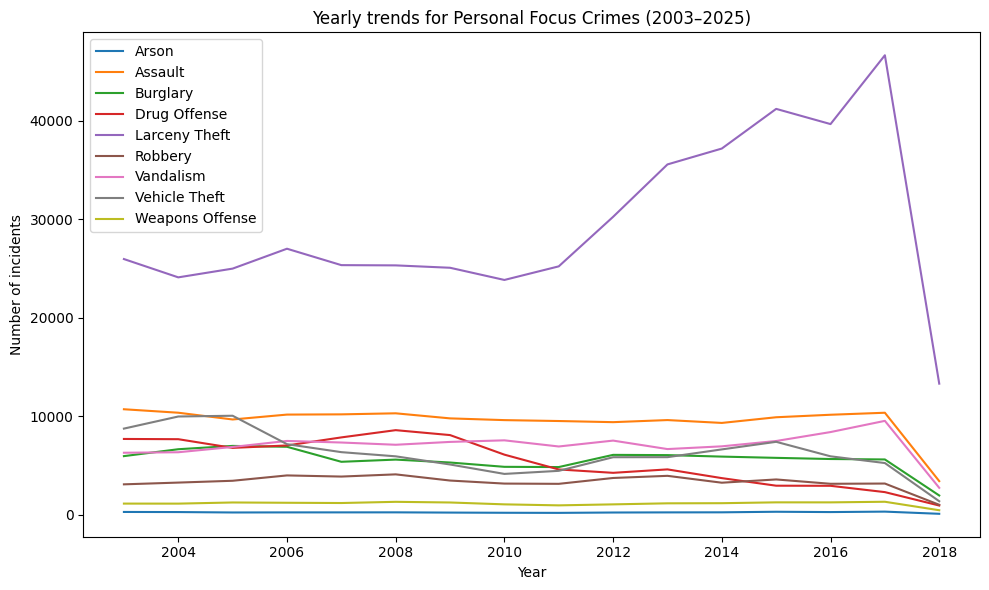

In [1]:
# Step 1.1: Temporal overview

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df['Incident Datetime'] = pd.to_datetime(df['Incident Datetime'], errors='coerce')
df['year'] = df['Incident Datetime'].dt.year

df = df[(df['year'] >= 2003) & (df['year'] <= 2025)]

# Focus crimes
focus_crimes = [
    "Assault", "Burglary", "Robbery", "Arson",
    "Vandalism", "Vehicle Theft", "Larceny Theft",
    "Drug Offense", "Weapons Offense"
]

df = df[df['Unified Category'].isin(focus_crimes)]

yearly_counts = (
    df.groupby(['year', 'Unified Category'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10, 6))

for crime in yearly_counts.columns:
    plt.plot(yearly_counts.index, yearly_counts[crime], label=crime)

plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.title("Yearly trends for Personal Focus Crimes (2003–2025)")
plt.legend()
plt.tight_layout()
plt.show()

#### Step 1.1: Observations

- From the plot, we observe a sharp drop in 2018 across all crime types. This is unlikely to reflect a real decrease in crime, but instead is likely due to the dataset switch between historical and recent data, meaning 2018 is incomplete and should be interpreted cautiously.

- The plot shows that Larceny Theft increases significantly from around 2011 to 2017, peaking before the drop. This could reflect increased reporting, population growth, or more opportunities for theft in busy urban areas.

- Additionally, the figure indicates that several crimes (e.g. burglary, robbery, vehicle theft) remain relatively stable or show slight declines over time, suggesting that not all crime types follow the same long-term trend.

---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

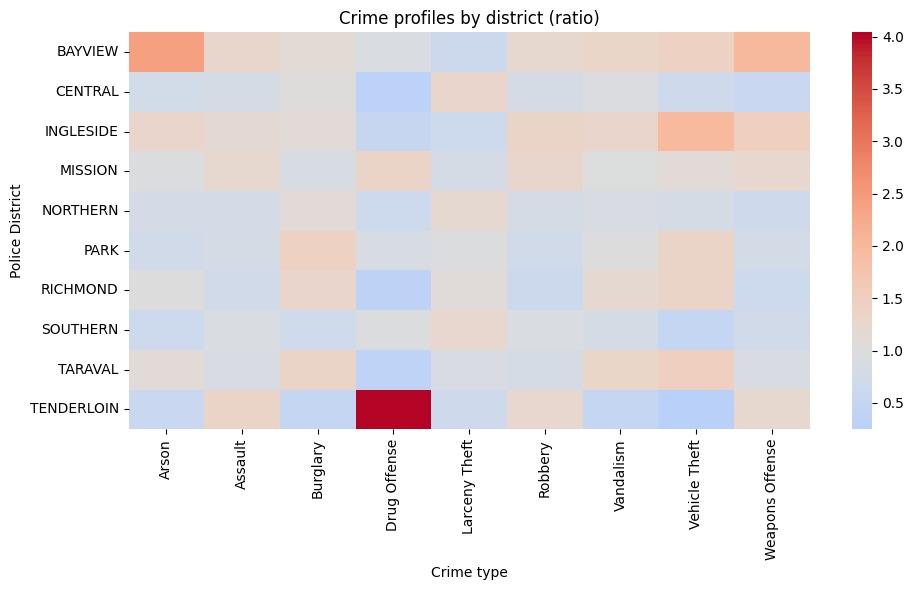

In [2]:
# Step 1.2: Crime profiles by police district

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df["Police District"] = df["Police District"].str.upper()
df = df[df["Police District"] != "OUT OF SF"]

focus_crimes = [
    "Assault", "Burglary", "Robbery", "Arson",
    "Vandalism", "Vehicle Theft", "Larceny Theft",
    "Drug Offense", "Weapons Offense"
]

df = df[df["Unified Category"].isin(focus_crimes)]

# P(crime)
p_crime = df["Unified Category"].value_counts(normalize=True)

# P(crime | district)
p_cd = (
    df.groupby("Police District")["Unified Category"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

# Ratio
ratio = p_cd.divide(p_crime, axis=1)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(ratio, cmap="coolwarm", center=1)
plt.title("Crime profiles by district (ratio)")
plt.xlabel("Crime type")
plt.ylabel("Police District")
plt.tight_layout()
plt.show()

#### Step 1.2: Observations

- From the heatmap, Tenderloin clearly stands out with a very high ratio for drug offenses (far above 1), meaning drug-related crime is heavily concentrated there. This likely reflects known open drug markets and increased police attention in that area.

- The heatmap also shows that Bayview has relatively higher values for violent crimes like assault and robbery compared to the city average. This suggests a distinct crime profile focused more on violent incidents rather than property crime.

- In contrast, districts such as Richmond and Taraval show higher ratios for burglary and vehicle theft, while being lower on violent crimes. This pattern is consistent with more residential areas where property crime is more common than street-level or drug-related crime.

---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>
> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?
>
> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

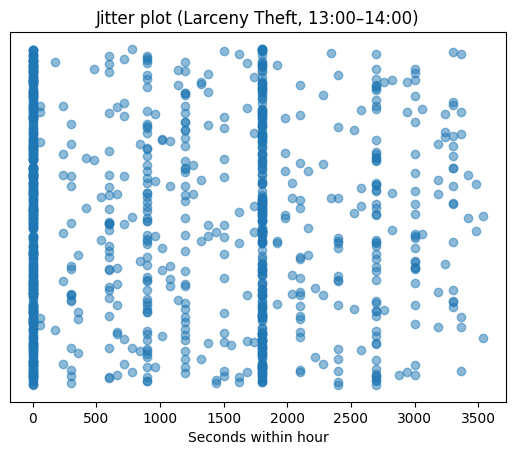

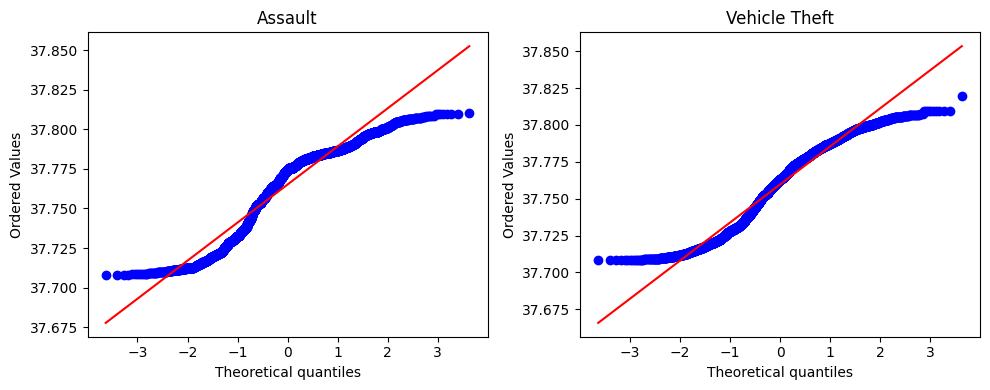

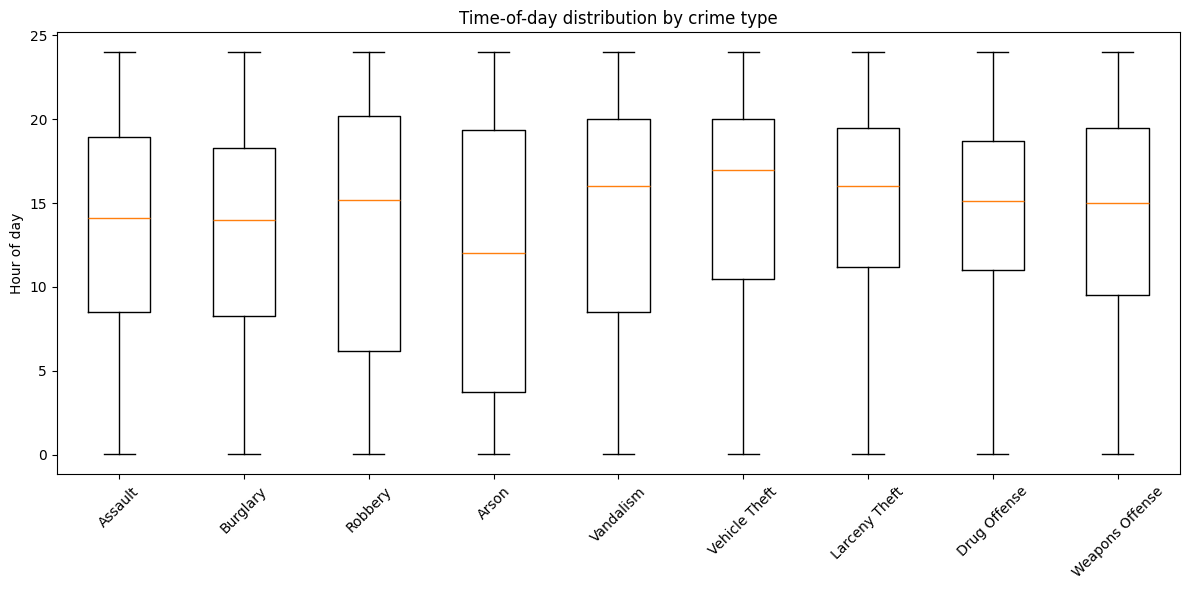

In [3]:
# Step 1.3: Visualizing Distributions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import probplot

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")
df = df.dropna(subset=["Incident Datetime", "Latitude", "Unified Category"])

focus_crimes = [
    "Assault", "Burglary", "Robbery", "Arson",
    "Vandalism", "Vehicle Theft", "Larceny Theft",
    "Drug Offense", "Weapons Offense"
]

df = df[df["Unified Category"].isin(focus_crimes)]


# Part A: Jitter plot
crime = "Larceny Theft"  # more common

df_c = df[df["Unified Category"] == crime]

df_c = df_c[
    (df_c["Incident Datetime"] >= "2015-01-01") &
    (df_c["Incident Datetime"] <= "2015-06-30")
]

df_hour = df_c[df_c["Incident Datetime"].dt.hour == 13]

seconds = (
    df_hour["Incident Datetime"].dt.minute * 60 +
    df_hour["Incident Datetime"].dt.second
)

jitter = np.random.uniform(-0.5, 0.5, size=len(seconds))

plt.figure()
plt.scatter(seconds, jitter, alpha=0.5)
plt.xlabel("Seconds within hour")
plt.yticks([])
plt.title("Jitter plot (Larceny Theft, 13:00–14:00)")
plt.show()


# Part B: Probability plot (QQ)
crime1 = "Assault"
crime2 = "Vehicle Theft"

lat1 = df[df["Unified Category"] == crime1]["Latitude"].dropna()
lat2 = df[df["Unified Category"] == crime2]["Latitude"].dropna()

# filter SF bounds
lat1 = lat1[(lat1 > 37.70) & (lat1 < 37.82)]
lat2 = lat2[(lat2 > 37.70) & (lat2 < 37.82)]

# sample
lat1 = lat1.sample(5000, random_state=42)
lat2 = lat2.sample(5000, random_state=42)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
probplot(lat1, dist="norm", plot=plt)
plt.title(crime1)

plt.subplot(1, 2, 2)
probplot(lat2, dist="norm", plot=plt)
plt.title(crime2)

plt.tight_layout()
plt.show()


# Part C: Box plots (time of day)
df["hour"] = (
    df["Incident Datetime"].dt.hour +
    df["Incident Datetime"].dt.minute / 60
)

data = [
    df[df["Unified Category"] == crime]["hour"].dropna()
    for crime in focus_crimes
]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=focus_crimes, showfliers=False)
plt.xticks(rotation=45)
plt.ylabel("Hour of day")
plt.title("Time-of-day distribution by crime type")
plt.tight_layout()
plt.show()

#### Step 1.3: Observations

**Part A — Jitter plot**
- From the jitter plot, we observe clear vertical lines at specific time values (e.g. 0, ~1800 seconds), meaning many incidents are recorded at exact minutes like :00 or :30.
- This indicates that timestamps are often rounded rather than precisely measured, suggesting limited temporal precision in the dataset.

**Part B — Probability plot**
- The reference distribution is a normal distribution.
- If the points followed the straight line exactly, it would indicate that crime locations are normally distributed across latitude.
- Instead, the plots show an S-shaped deviation from the line, indicating that the distribution is not normal and that crime is concentrated in specific geographic areas rather than evenly distributed.

**Part C — Box plots**
- From the box plots, we observe that property crimes like vehicle theft and larceny theft tend to occur more during daytime and afternoon hours.
- Violent crimes such as robbery and assault are more spread out, with some tendency toward later hours.
- The box plot struggles with wrap-around at midnight, which makes late-night activity appear more spread out than it actually is.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

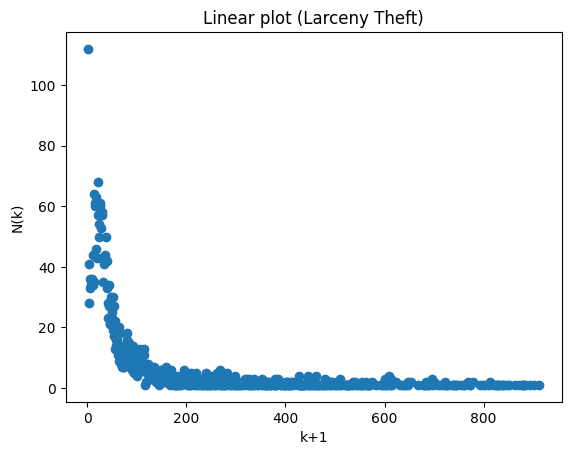

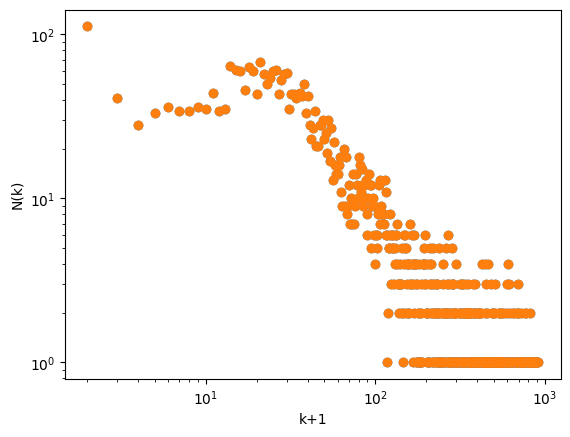

In [4]:
# Step 1.4: Spatial power law

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df = df[["Unified Category", "Latitude", "Longitude"]].dropna()

focus_crimes = [
    "Assault", "Burglary", "Robbery", "Arson",
    "Vandalism", "Vehicle Theft", "Larceny Theft",
    "Drug Offense", "Weapons Offense"
]

df = df[df["Unified Category"].isin(focus_crimes)]

# Step 0: pick most common crime
most_common = df["Unified Category"].value_counts().idxmax()

crime_df = df[df["Unified Category"] == most_common]

# Step 1: filter SF bounds
crime_df = crime_df[
    (crime_df["Longitude"] > -122.55) & (crime_df["Longitude"] < -122.35) &
    (crime_df["Latitude"] > 37.70) & (crime_df["Latitude"] < 37.82)
]

# Step 2: grid
xbins = np.linspace(crime_df["Longitude"].min(), crime_df["Longitude"].max(), 80)
ybins = np.linspace(crime_df["Latitude"].min(), crime_df["Latitude"].max(), 80)

H, _, _ = np.histogram2d(crime_df["Longitude"], crime_df["Latitude"], bins=[xbins, ybins])

# Step 3: compute N(k)
counts = H.flatten().astype(int)

# remove extreme outliers (very large k)
counts = counts[counts < np.percentile(counts, 99)]

k_vals, Nk = np.unique(counts, return_counts=True)

# remove k=0 dominance for clearer plot
mask = k_vals > 0
k_vals = k_vals[mask]
Nk = Nk[mask]

# Step 4: linear plot
plt.figure()
plt.plot(k_vals + 1, Nk, 'o')
plt.xlabel("k+1")
plt.ylabel("N(k)")
plt.title(f"Linear plot ({most_common})")
plt.show()

# Step 5: log-log plot
plt.figure()
plt.loglog(k_vals + 1, Nk, 'o')
plt.xlabel("k+1")
plt.ylabel("N(k)")
plt.loglog(k_vals + 1, Nk, 'o')
plt.show()

#### Step 1.4: Observations

- From the log-log plot, we observe a clear downward trend that is approximately linear over a range of values, indicating a power-law-like distribution. This means that most grid cells contain very few incidents, while a small number of cells contain many.

- The linear plot further highlights this imbalance, showing that a large number of cells have low counts, while only a few cells have very high counts.

- Together, the plots indicate that crime is not evenly distributed across the city, but instead highly concentrated in specific hotspots.

- Because of this strong concentration, the concept of an "average block" is not very meaningful. Most areas experience little crime, while a few areas dominate the statistics, so averages can be misleading when interpreting neighborhood safety.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

*Draws from*: Week 4, Exercises 3.1, 3.2, and 3.3.

Select **at least 4** of your Personal Focus Crimes for this exercise. More is fine - if you want to be closer to the actual weekly exercise.

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.
>
> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.
>
> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$
>
> * **$R^2$**: Compute $R^2$ for each pair and display the value on each panel. 
>
> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

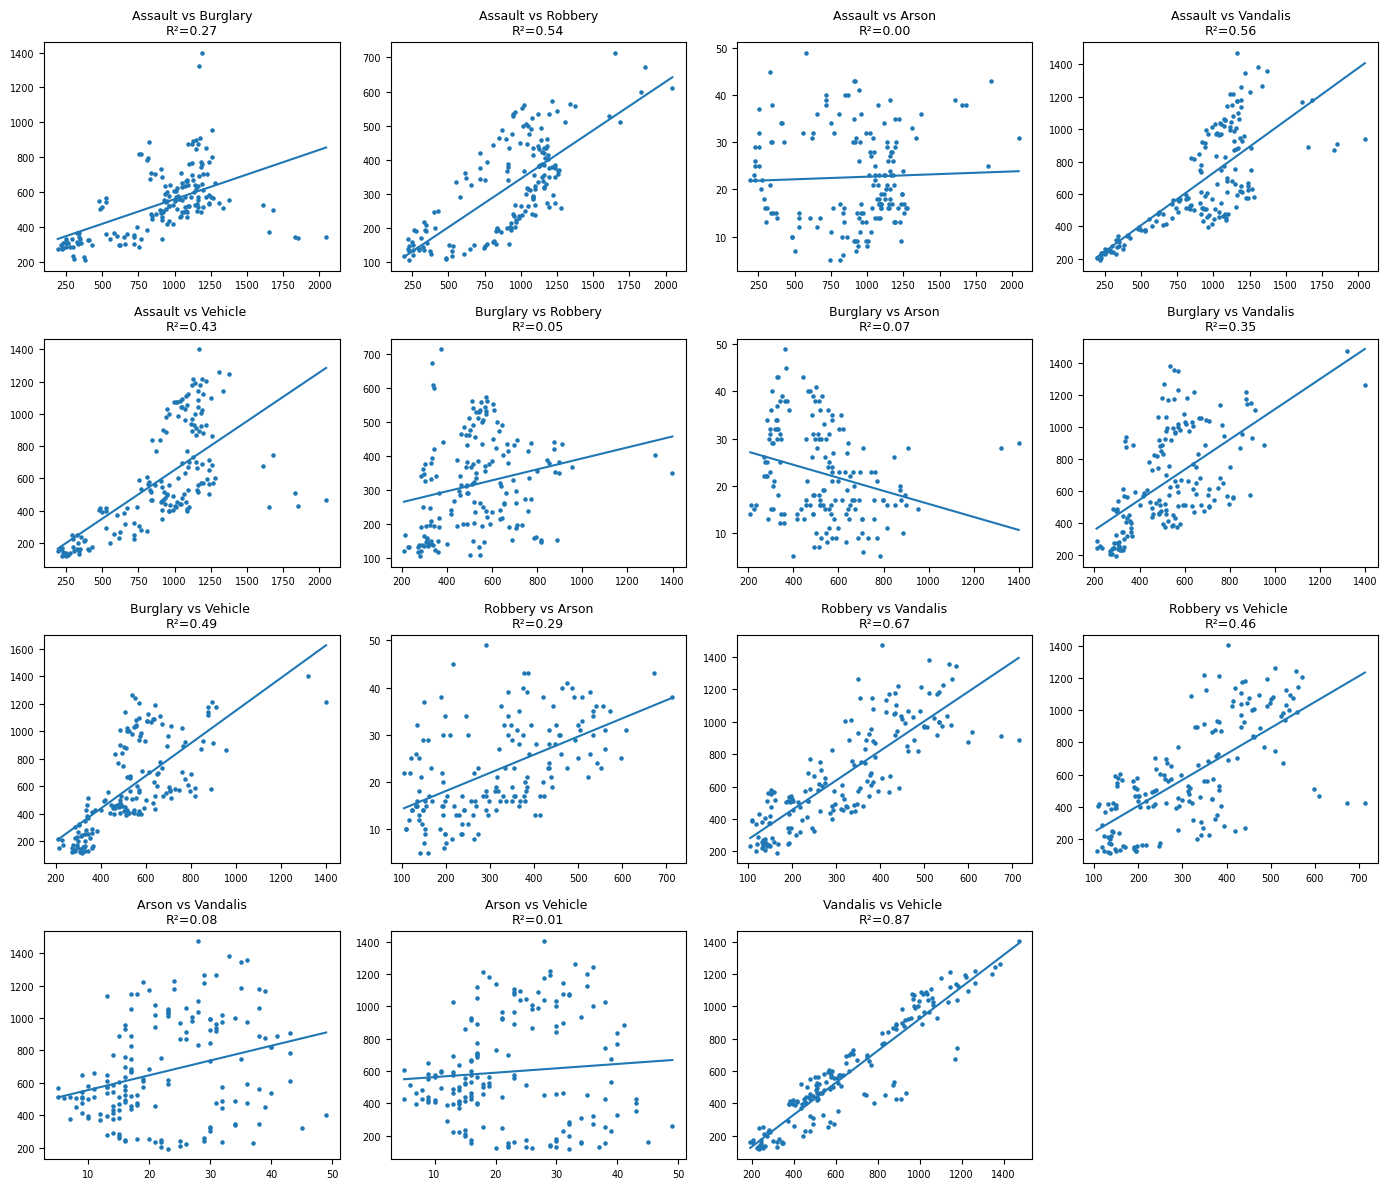

(('Vandalism', 'Vehicle Theft'), ('Assault', 'Arson'))

In [5]:
# Step 1.5: Regression and correlation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

df = pd.read_csv("../../dataset/Week2/merged_police_incidents.csv")

df["Incident Datetime"] = pd.to_datetime(df["Incident Datetime"], errors="coerce")
df = df.dropna(subset=["Incident Datetime", "Unified Category"])

focus_crimes = [
    "Assault", "Burglary", "Robbery", "Arson",
    "Vandalism", "Vehicle Theft", "Larceny Theft",
    "Drug Offense", "Weapons Offense"
]

# use subset (at least 4)
selected = focus_crimes[:6]

df = df[df["Unified Category"].isin(selected)]

# hour of week
df["hour_of_week"] = (
    df["Incident Datetime"].dt.dayofweek * 24 +
    df["Incident Datetime"].dt.hour
)

# aggregate
pivot = (
    df.groupby(["hour_of_week", "Unified Category"])
    .size()
    .unstack(fill_value=0)
)

pairs = list(itertools.combinations(selected, 2))

n = len(pairs)
cols = 4
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 12))
axes = axes.flatten()

r2_results = {}

for i, (c1, c2) in enumerate(pairs):
    ax = axes[i]
    
    x = pivot[c1].values
    y = pivot[c2].values
    N = len(x)
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    a = (np.sum(x*y) - N*x_mean*y_mean) / (np.sum(x**2) - N*x_mean**2)
    b = y_mean - a*x_mean
    
    y_pred = a*x + b
    
    ss_res = np.sum((y - y_pred)**2)
    ss_tot = np.sum((y - y_mean)**2)
    r2 = 1 - ss_res/ss_tot
    
    r2_results[(c1, c2)] = r2
    
    ax.scatter(x, y, s=5)
    
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, a*x_line + b)
    
    ax.set_title(f"{c1[:8]} vs {c2[:8]}\nR²={r2:.2f}", fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(len(pairs), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# find best / worst
best_pair = max(r2_results, key=r2_results.get)
worst_pair = min(r2_results, key=r2_results.get)

best_pair, worst_pair

#### Step 1.5: Observations

- The regression coefficients and $R^2$ values are computed using the closed-form formulas introduced in the Week 4 lecture.

- From the scatterplot matrix, we observe that the most correlated pair is **Vandalism vs Vehicle Theft (R² ≈ 0.87)**. This very high value indicates that these two crime types follow almost the same weekly pattern. This makes sense, as both are property-related crimes and likely occur under similar conditions, such as busy urban activity periods or times when vehicles are unattended.

- Another relatively strong correlation is **Robbery vs Vandalism (R² ≈ 0.67)**, suggesting some shared temporal patterns, possibly linked to nighttime activity or areas with higher street presence.

- The least correlated pair is **Assault vs Arson (R² ≈ 0.00)**, meaning there is essentially no linear relationship between their weekly patterns. This suggests these crimes occur in very different contexts and times.

- Additionally, **Arson vs Vehicle Theft (R² ≈ 0.01)** also shows almost no correlation, reinforcing that arson behaves very differently from more common property crimes.

- Overall, the plots indicate that crimes related to similar environments (e.g., property crimes in urban areas) tend to have stronger correlations, while more rare or context-specific crimes (like arson) show weak or no correlation with others.

- This matches intuition: common crimes tied to daily human activity patterns align more closely, while rare or specialized crimes do not follow the same weekly rhythm.